# NB 04: Structure Selection via PC2 Correlation

**Objective**: Determine which option structures' PnL is most correlated with the PC2 skew factor.
Instead of assuming which structure captures PC2 mean reversion, let the data identify the best factor-mimicking portfolio.

**Methodology**:
1. Define a universe of put-wing option structures (BWBs, ratio spreads, put spreads) at various delta placements
2. For each structure, compute monthly holding-period PnL (Friday entry, 3-month expiry, 1-month hold, roll)
3. All structures evaluated from the **SHORT** side (vega-normalized). Long is just the opposite sign.
4. Correlate each structure's PnL with:
   - **PC2 level at entry** -- does the mean reversion signal predict returns?
   - **$\Delta$PC2 over holding period** -- which structure's PnL is most mechanically driven by PC2 moves?
5. Multivariate regression: PnL ~ $\Delta$PC2 + $\Delta$VIX + $\Delta$S to isolate pure PC2 loading

**Key Question**: Which option structure is the purest expression of PC2 (skew factor)?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from collections import defaultdict
from scipy import stats

from trade_data import (
    load_market_data, load_vol_features,
    OptionLeg, OptionStructure, OptionType, LegSide,
)

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

PARENT_DIR = os.path.abspath('..')

## 1. Load Data

In [2]:
# Load market data
print('Loading market data...')
df_market = load_market_data().collect()
df_market = df_market.filter(pl.col('date') >= datetime.date(2016, 1, 1))
print(f'  {df_market.height:,} rows, {df_market["date"].n_unique()} dates')

# Pre-filter for put leg selection: OTM puts with tight IV spread
df_selection = (
    df_market
    .filter(
        (pl.col('cp') == 'Put') &
        (pl.col('u_price') > pl.col('strike'))
    )
    .with_columns((pl.col('ask_vol') - pl.col('bid_vol')).abs().alias('spreadIV'))
    .filter(
        ((pl.col('spreadIV') / pl.col('surface_vol')) < 0.1) &
        (pl.col('bid_vol') > 0) & (pl.col('ask_vol') > 0)
    )
)
print(f'  Selection pool (OTM puts, tight spread): {df_selection.height:,} rows')

# Load vol features
vol_features = load_vol_features()
print(f'  Vol features: {vol_features.height:,} rows')

# Load walk-forward PC2
wf = pl.read_parquet(os.path.join(PARENT_DIR, 'data/walk_forward_results_month_end.parquet'))
print(f'  Walk-forward: {wf.height} monthly obs, {wf["date"].min()} to {wf["date"].max()}')

# Build daily PC2 signal (forward-filled from month-end)
all_dates = df_market.select('date').unique().sort('date')
daily_pc2 = (
    all_dates
    .join(
        wf.select(['date', 'pc2_score']).rename({'date': 'date'}),
        on='date',
        how='left',
    )
    .sort('date')
    .with_columns(pl.col('pc2_score').forward_fill())
    .drop_nulls(subset=['pc2_score'])
)
print(f'  Daily PC2: {daily_pc2.height} dates '
      f'({daily_pc2["date"].min()} to {daily_pc2["date"].max()})')

Loading market data...
  29,770,075 rows, 2547 dates
  Selection pool (OTM puts, tight spread): 8,654,778 rows
  Vol features: 3,793 rows
  Walk-forward: 98 monthly obs, 2018-02-28 to 2026-03-19
  Daily PC2: 2024 dates (2018-02-28 to 2026-03-19)


## 2. Structure Universe

Define option structures to evaluate. All evaluated from the **SHORT** side.

**Easy to extend** -- add new `OptionStructure` entries to the `STRUCTURES` list.

In [12]:
# ============================================================
# STRUCTURE UNIVERSE -- edit this list to add/remove structures
# ============================================================

STRUCTURES = [
    # --- Broken Wing Butterflies (BWB) ---
    # Long: Buy wing1 (deep OTM), Sell 2x body, Buy wing2 (closer ATM)
    # Short (what we evaluate): Sell wing1, Buy 2x body, Sell wing2
    OptionStructure('BWB_5_10_15', (
        OptionLeg('w1', OptionType.PUT, 0.05, LegSide.LONG, 1),
        OptionLeg('body', OptionType.PUT, 0.10, LegSide.SHORT, 2),
        OptionLeg('w2', OptionType.PUT, 0.15, LegSide.LONG, 1),
    )),
    OptionStructure('BWB_10_15_20', (
        OptionLeg('w1', OptionType.PUT, 0.10, LegSide.LONG, 1),
        OptionLeg('body', OptionType.PUT, 0.15, LegSide.SHORT, 2),
        OptionLeg('w2', OptionType.PUT, 0.20, LegSide.LONG, 1),
    )),
    OptionStructure('BWB_10_20_30', (
        OptionLeg('w1', OptionType.PUT, 0.10, LegSide.LONG, 1),
        OptionLeg('body', OptionType.PUT, 0.20, LegSide.SHORT, 2),
        OptionLeg('w2', OptionType.PUT, 0.30, LegSide.LONG, 1),
    )),
    OptionStructure('BWB_5_15_25', (
        OptionLeg('w1', OptionType.PUT, 0.05, LegSide.LONG, 1),
        OptionLeg('body', OptionType.PUT, 0.15, LegSide.SHORT, 2),
        OptionLeg('w2', OptionType.PUT, 0.25, LegSide.LONG, 1),
    )),
    OptionStructure('BWB_15_20_25', (
        OptionLeg('w1', OptionType.PUT, 0.15, LegSide.LONG, 1),
        OptionLeg('body', OptionType.PUT, 0.20, LegSide.SHORT, 2),
        OptionLeg('w2', OptionType.PUT, 0.25, LegSide.LONG, 1),
    )),

    # --- Ratio Spreads (1x2) ---
    # Long: Buy 1x higher-delta, Sell 2x lower-delta
    # Short: Sell 1x higher-delta, Buy 2x lower-delta
    OptionStructure('Ratio_25_10', (
        OptionLeg('buy', OptionType.PUT, 0.25, LegSide.LONG, 1),
        OptionLeg('sell', OptionType.PUT, 0.10, LegSide.SHORT, 2),
    )),
    OptionStructure('Ratio_20_10', (
        OptionLeg('buy', OptionType.PUT, 0.20, LegSide.LONG, 1),
        OptionLeg('sell', OptionType.PUT, 0.10, LegSide.SHORT, 2),
    )),
    OptionStructure('Ratio_15_5', (
        OptionLeg('buy', OptionType.PUT, 0.15, LegSide.LONG, 1),
        OptionLeg('sell', OptionType.PUT, 0.05, LegSide.SHORT, 2),
    )),
    OptionStructure('Ratio_30_15', (
        OptionLeg('buy', OptionType.PUT, 0.30, LegSide.LONG, 1),
        OptionLeg('sell', OptionType.PUT, 0.15, LegSide.SHORT, 2),
    )),
    OptionStructure('New', (
        OptionLeg('buy', OptionType.PUT, 0.25, LegSide.LONG, 1),
        OptionLeg('sell', OptionType.PUT, 0.05, LegSide.SHORT, 5),
    )),
    # --- Put Spreads (1x1) ---
    # Long: Buy higher-delta (closer ATM), Sell lower-delta (deeper OTM)
    # Short: Sell higher-delta, Buy lower-delta
    OptionStructure('Spread_25_10', (
        OptionLeg('high', OptionType.PUT, 0.25, LegSide.LONG, 1),
        OptionLeg('low', OptionType.PUT, 0.10, LegSide.SHORT, 1),
    )),
    OptionStructure('Spread_20_5', (
        OptionLeg('high', OptionType.PUT, 0.20, LegSide.LONG, 1),
        OptionLeg('low', OptionType.PUT, 0.05, LegSide.SHORT, 1),
    )),
    OptionStructure('Spread_15_5', (
        OptionLeg('high', OptionType.PUT, 0.15, LegSide.LONG, 1),
        OptionLeg('low', OptionType.PUT, 0.05, LegSide.SHORT, 1),
    )),
]

print(f'Structure universe: {len(STRUCTURES)} structures')
for s in STRUCTURES:
    deltas = ', '.join(f'{leg.target_delta*100:.0f}d' for leg in s.legs)
    ratios = ', '.join(f'{leg.ratio}x' for leg in s.legs)
    print(f'  {s.name:20s}  deltas=({deltas})  ratios=({ratios})')

Structure universe: 13 structures
  BWB_5_10_15           deltas=(5d, 10d, 15d)  ratios=(1x, 2x, 1x)
  BWB_10_15_20          deltas=(10d, 15d, 20d)  ratios=(1x, 2x, 1x)
  BWB_10_20_30          deltas=(10d, 20d, 30d)  ratios=(1x, 2x, 1x)
  BWB_5_15_25           deltas=(5d, 15d, 25d)  ratios=(1x, 2x, 1x)
  BWB_15_20_25          deltas=(15d, 20d, 25d)  ratios=(1x, 2x, 1x)
  Ratio_25_10           deltas=(25d, 10d)  ratios=(1x, 2x)
  Ratio_20_10           deltas=(20d, 10d)  ratios=(1x, 2x)
  Ratio_15_5            deltas=(15d, 5d)  ratios=(1x, 2x)
  Ratio_30_15           deltas=(30d, 15d)  ratios=(1x, 2x)
  New                   deltas=(25d, 5d)  ratios=(1x, 5x)
  Spread_25_10          deltas=(25d, 10d)  ratios=(1x, 1x)
  Spread_20_5           deltas=(20d, 5d)  ratios=(1x, 1x)
  Spread_15_5           deltas=(15d, 5d)  ratios=(1x, 1x)


## 3. Monthly Friday Schedule & PnL Functions

- **Entry**: First Friday of each month
- **Exit**: First Friday of next month (~1 month hold)
- **Expiry**: Target 90 calendar days (3 months) at entry
- **PnL**: Vega-normalized (100 abs vega at entry), SHORT perspective

In [13]:
TARGET_DTE_YEARS = 90 / 365   # 3-month target expiry
MIN_DTE_YEARS = 60 / 365
MAX_DTE_YEARS = 150 / 365


def generate_monthly_fridays(trading_dates: list) -> list:
    """First Friday of each month from available trading dates."""
    months: dict[tuple, list] = defaultdict(list)
    for d in trading_dates:
        if d.weekday() == 4:  # Friday
            months[(d.year, d.month)].append(d)
    return [min(months[k]) for k in sorted(months.keys())]


def select_legs(df_date, structure,
                target_dte=TARGET_DTE_YEARS,
                min_dte=MIN_DTE_YEARS,
                max_dte=MAX_DTE_YEARS):
    """Select option legs for a structure on a given trading date.

    Returns dict {leg_label: row_dict} or None if any leg fails.
    """
    if df_date.height == 0:
        return None

    # 1. Find expiry closest to target_dte (in years)
    expiries = (
        df_date.select(['expiration', 't_years'])
        .filter((pl.col('t_years') >= min_dte) & (pl.col('t_years') <= max_dte))
        .with_columns((pl.col('t_years') - target_dte).abs().alias('dte_diff'))
        .sort('dte_diff')
    )
    if expiries.height == 0:
        return None

    best_expiry = expiries['expiration'][0]
    df_expiry = df_date.filter(pl.col('expiration') == best_expiry)

    # 2. For each leg, find strike closest to target_delta (absolute)
    legs = {}
    for leg in structure.legs:
        candidates = (
            df_expiry
            .filter(pl.col('cp') == leg.option_type.value)
            .with_columns(
                (pl.col('delta').abs() - leg.target_delta).abs().alias('delta_diff')
            )
            .sort('delta_diff')
        )
        if candidates.height == 0:
            return None
        legs[leg.label] = candidates.row(0, named=True)

    return legs


def compute_holding_pnl(price_index, entry_legs, exit_date, structure):
    """Compute vega-normalized holding PnL from the SHORT perspective.

    Args:
        price_index: dict (date, expiration, strike) -> c_price
        entry_legs: dict from select_legs()
        exit_date: date to look up exit prices
        structure: OptionStructure

    Returns dict with holding_pnl and metadata, or None.
    """
    total_long_pnl = 0.0
    total_abs_vega = 0.0
    total_signed_delta = 0.0

    for leg in structure.legs:
        info = entry_legs[leg.label]
        key = (exit_date, info['expiration'], info['strike'])
        exit_price = price_index.get(key)
        if exit_price is None:
            return None

        entry_price = info['c_price']
        long_pnl = leg.pnl_sign() * leg.ratio * (exit_price - entry_price)
        total_long_pnl += long_pnl
        total_abs_vega += abs(info['vega']) * leg.ratio
        total_signed_delta += leg.pnl_sign() * leg.ratio * info['delta']

    if total_abs_vega == 0:
        return None

    vega_scale = 100.0 / total_abs_vega
    return {
        'holding_pnl': -total_long_pnl * vega_scale,   # SHORT = negate long
        'entry_net_delta': total_signed_delta,
        'entry_abs_vega': total_abs_vega,
        'vega_scale': vega_scale,
    }


# --- Generate schedule ---
all_trading_dates = sorted(df_market['date'].unique().to_list())
entry_fridays = generate_monthly_fridays(all_trading_dates)
print(f'Monthly Friday schedule: {len(entry_fridays)} dates')
print(f'  First: {entry_fridays[0]},  Last: {entry_fridays[-1]}')

# Trim to PC2 coverage
pc2_start = daily_pc2['date'].min()
entry_fridays = [d for d in entry_fridays if d >= pc2_start]
print(f'  After PC2 filter: {len(entry_fridays)} (from {entry_fridays[0]})')

# Entry/exit pairs
entry_exit_pairs = list(zip(entry_fridays[:-1], entry_fridays[1:]))
print(f'  Entry/exit pairs: {len(entry_exit_pairs)}')

Monthly Friday schedule: 123 dates
  First: 2016-01-08,  Last: 2026-03-06
  After PC2 filter: 97 (from 2018-03-02)
  Entry/exit pairs: 96


## 4. Compute Holding-Period PnL

For each (entry_date, structure) pair:
1. Select legs on entry (3-month expiry, closest delta)
2. Look up exit prices on first Friday of next month
3. Compute vega-normalized PnL (SHORT perspective)
4. Record PC2, VIX, underlying at entry and exit

In [14]:
# Build fast lookup indices
print('Building lookup indices...')

# Price index: (date, expiration, strike) -> c_price
_price_raw = df_market.select(['date', 'expiration', 'strike', 'c_price'])
price_index = {}
for row in _price_raw.iter_rows():
    price_index[(row[0], row[1], row[2])] = row[3]
print(f'  Price index: {len(price_index):,} entries')

# PC2, VIX, underlying lookups
pc2_lookup = dict(zip(
    daily_pc2['date'].to_list(),
    daily_pc2['pc2_score'].to_list(),
))

_vf = vol_features.select(['date', 'VIX', 'VVIX']).unique(subset=['date'])
vix_dict = dict(zip(_vf['date'].to_list(), _vf['VIX'].to_list()))
vvix_dict = dict(zip(_vf['date'].to_list(), _vf['VVIX'].to_list()))

_uc = df_market.select(['date', 'u_price']).unique(subset=['date'])
uclose_dict = dict(zip(_uc['date'].to_list(), _uc['u_price'].to_list()))

# Pre-partition selection data by entry date
print('Partitioning selection data...')
selection_by_date = {}
entry_date_set = set(d for d, _ in entry_exit_pairs)
for date in entry_date_set:
    selection_by_date[date] = df_selection.filter(pl.col('date') == date)

# --- Main loop ---
print(f'\nProcessing {len(entry_exit_pairs)} months x {len(STRUCTURES)} structures...')
results = []
n_skip = 0

for i, (entry_date, exit_date) in enumerate(entry_exit_pairs):
    df_entry = selection_by_date.get(entry_date)
    if df_entry is None or df_entry.height == 0:
        n_skip += len(STRUCTURES)
        continue

    # Lookup env variables once per entry date
    pc2_e = pc2_lookup.get(entry_date)
    pc2_x = pc2_lookup.get(exit_date)
    vix_e = vix_dict.get(entry_date)
    vix_x = vix_dict.get(exit_date)
    vvix_e = vvix_dict.get(entry_date)
    uc_e = uclose_dict.get(entry_date)
    uc_x = uclose_dict.get(exit_date)

    if any(v is None for v in [pc2_e, pc2_x, vix_e, vix_x, uc_e, uc_x]):
        n_skip += len(STRUCTURES)
        continue

    for structure in STRUCTURES:
        legs = select_legs(df_entry, structure)
        if legs is None:
            n_skip += 1
            continue

        pnl_result = compute_holding_pnl(price_index, legs, exit_date, structure)
        if pnl_result is None:
            n_skip += 1
            continue

        results.append({
            'entry_date': entry_date,
            'exit_date': exit_date,
            'structure': structure.name,
            'holding_pnl': pnl_result['holding_pnl'],
            'entry_net_delta': pnl_result['entry_net_delta'],
            'entry_abs_vega': pnl_result['entry_abs_vega'],
            'pc2_entry': pc2_e,
            'pc2_exit': pc2_x,
            'delta_pc2': pc2_x - pc2_e,
            'vix_entry': vix_e,
            'vix_exit': vix_x,
            'delta_vix': vix_x - vix_e,
            'vvix_entry': vvix_e,
            'uclose_entry': uc_e,
            'uclose_exit': uc_x,
            'return_underlying': (uc_x / uc_e) - 1.0,
        })

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(entry_exit_pairs)} months done...')

results_df = pl.DataFrame(results)
print(f'\nDone: {results_df.height} observations ({n_skip} skipped)')
print(f'  Structures: {results_df["structure"].n_unique()}')
print(f'  Months: {results_df["entry_date"].n_unique()}')
n_per = results_df.group_by('structure').len().sort('structure')
print(f'  Per structure: {n_per["len"].min()}-{n_per["len"].max()} obs')

Building lookup indices...
  Price index: 14,898,911 entries
Partitioning selection data...

Processing 96 months x 13 structures...
  20/96 months done...
  40/96 months done...
  60/96 months done...
  80/96 months done...

Done: 1222 observations (26 skipped)
  Structures: 13
  Months: 94
  Per structure: 94-94 obs


## 5. PC2 Correlation Analysis

Two key correlations for each structure:

1. **corr(Short PnL, $\Delta$PC2)** -- factor exposure: which structure's PnL is most mechanically driven by PC2 changes?

2. **corr(Short PnL, PC2 entry)** -- signal predictability: does the level of PC2 at entry predict next month's returns?

In [15]:
# Compute correlations for each structure
corr_pc2_entry = {}
corr_delta_pc2 = {}
mean_pnl = {}
std_pnl = {}

for s in STRUCTURES:
    subset = results_df.filter(pl.col('structure') == s.name)
    pnl = subset['holding_pnl'].to_numpy()
    pc2_e = subset['pc2_entry'].to_numpy()
    d_pc2 = subset['delta_pc2'].to_numpy()

    corr_pc2_entry[s.name] = stats.spearmanr(pnl, pc2_e).statistic
    corr_delta_pc2[s.name] = stats.spearmanr(pnl, d_pc2).statistic
    mean_pnl[s.name] = np.mean(pnl)
    std_pnl[s.name] = np.std(pnl)

# Sort by abs(corr_delta_pc2)
sorted_names = sorted(STRUCTURES, key=lambda s: abs(corr_delta_pc2[s.name]), reverse=True)

print('Correlation: Short PnL vs PC2')
print(f'{"Structure":20s} {"corr(PnL,PC2_entry)":>20s} {"corr(PnL,dPC2)":>16s} '
      f'{"mean_pnl":>10s} {"std_pnl":>10s}')
print('-' * 80)
for s in sorted_names:
    print(f'{s.name:20s} {corr_pc2_entry[s.name]:>+20.3f} {corr_delta_pc2[s.name]:>+16.3f} '
          f'{mean_pnl[s.name]:>+10.2f} {std_pnl[s.name]:>10.2f}')

Correlation: Short PnL vs PC2
Structure             corr(PnL,PC2_entry)   corr(PnL,dPC2)   mean_pnl    std_pnl
--------------------------------------------------------------------------------
Ratio_30_15                        -0.264           +0.427    +133.04    1140.27
New                                -0.306           +0.402    +489.33    3632.59
BWB_10_15_20                       -0.254           +0.393      -4.46     718.57
Ratio_20_10                        -0.280           +0.371     +46.97    1381.66
BWB_5_15_25                        -0.203           +0.347      -1.30     741.43
Spread_20_5                        -0.246           +0.321    +163.83    1247.91
Ratio_25_10                        -0.257           +0.293    +127.93    1282.01
BWB_5_10_15                        -0.224           +0.278     -66.96    1480.43
Ratio_15_5                         -0.313           +0.272    +298.73    2417.48
Spread_25_10                       -0.180           +0.250    +131.91    1056.5

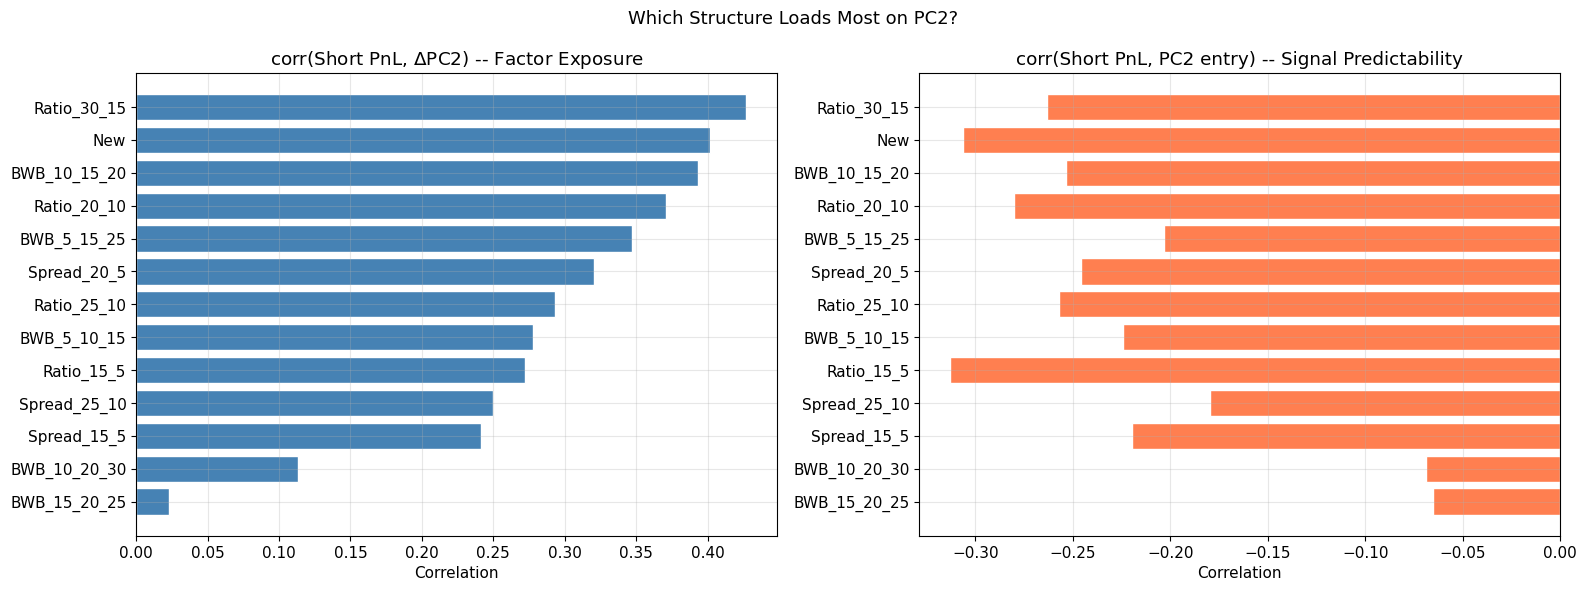

In [16]:
# Bar charts: correlation ranking
sorted_names_list = [s.name for s in sorted_names]
sorted_corr_dpc2 = [corr_delta_pc2[n] for n in sorted_names_list]
sorted_corr_pc2e = [corr_pc2_entry[n] for n in sorted_names_list]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# corr(PnL, delta_PC2)
colors = ['steelblue' if v >= 0 else 'coral' for v in sorted_corr_dpc2]
axes[0].barh(sorted_names_list[::-1], sorted_corr_dpc2[::-1],
             color=colors[::-1], edgecolor='white')
axes[0].set_xlabel('Correlation')
axes[0].set_title(r'corr(Short PnL, $\Delta$PC2) -- Factor Exposure')
axes[0].axvline(0, color='k', linewidth=0.5)

# corr(PnL, PC2_entry)
colors2 = ['steelblue' if v >= 0 else 'coral' for v in sorted_corr_pc2e]
axes[1].barh(sorted_names_list[::-1], sorted_corr_pc2e[::-1],
             color=colors2[::-1], edgecolor='white')
axes[1].set_xlabel('Correlation')
axes[1].set_title('corr(Short PnL, PC2 entry) -- Signal Predictability')
axes[1].axvline(0, color='k', linewidth=0.5)

fig.suptitle('Which Structure Loads Most on PC2?', fontsize=13)
fig.tight_layout()
plt.show()

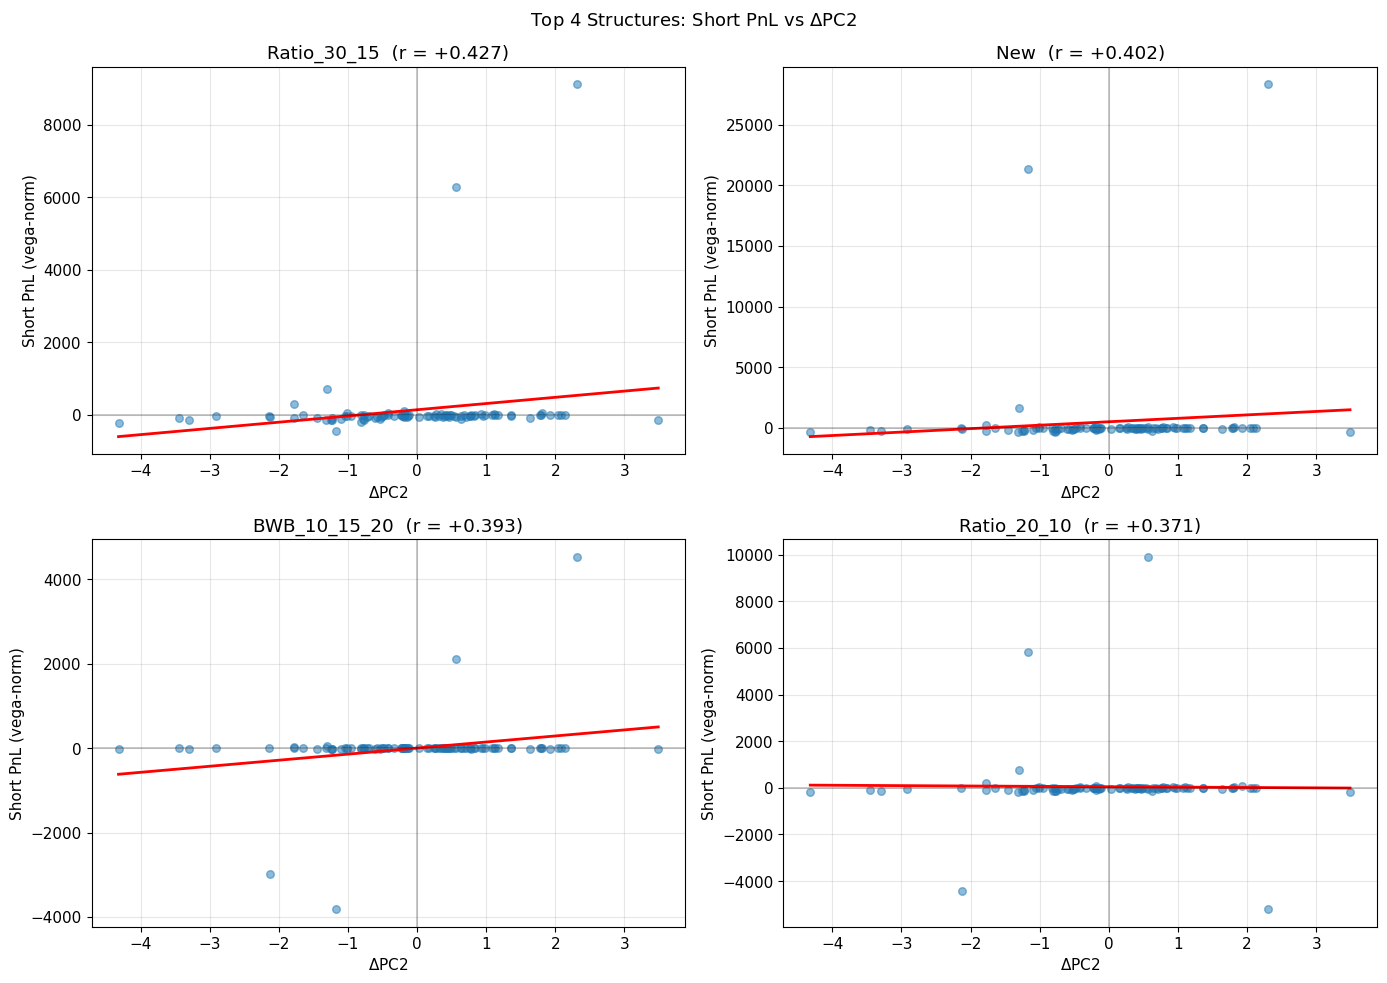

In [17]:
# Scatter: PnL vs delta_PC2 for top 4 structures
top4 = [s.name for s in sorted_names[:4]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, name in zip(axes.flat, top4):
    subset = results_df.filter(pl.col('structure') == name)
    pnl = subset['holding_pnl'].to_numpy()
    d_pc2 = subset['delta_pc2'].to_numpy()

    ax.scatter(d_pc2, pnl, alpha=0.5, s=30)
    # Regression line
    m, b = np.polyfit(d_pc2, pnl, 1)
    x_line = np.linspace(d_pc2.min(), d_pc2.max(), 50)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)

    r = corr_delta_pc2[name]
    ax.set_title(f'{name}  (r = {r:+.3f})')
    ax.set_xlabel(r'$\Delta$PC2')
    ax.set_ylabel('Short PnL (vega-norm)')
    ax.axhline(0, color='k', linewidth=0.3)
    ax.axvline(0, color='k', linewidth=0.3)

fig.suptitle(r'Top 4 Structures: Short PnL vs $\Delta$PC2', fontsize=13)
fig.tight_layout()
plt.show()

## 6. Multivariate Regression (Standardized)

$$\tilde{y}_i = \alpha + \beta_1 \widetilde{\Delta\text{PC2}}_i + \beta_2 \widetilde{\Delta\text{VIX}}_i + \beta_3 \widetilde{\Delta S}_i + \varepsilon_i$$

where $\tilde{x} = (x - \bar{x}) / \sigma_x$ denotes z-scoring. All variables standardized before OLS so betas are **standardized coefficients** (dimensionless): $\beta_j$ = change in PnL (in PnL std-devs) per 1-std move in regressor $j$.

This puts all structures on equal footing — betas are comparable across both regressors and structures regardless of each structure's raw PnL scale. The structure with the highest $|\beta_1|$ is the purest skew play.

In [18]:
print('Multivariate Regression (Standardized): PnL_z ~ dPC2_z + dVIX_z + dS_z')
print('='*90)

reg_results = []

for s in STRUCTURES:
    subset = results_df.filter(pl.col('structure') == s.name)

    y_raw = subset['holding_pnl'].to_numpy()
    X_raw = np.column_stack([
        subset['delta_pc2'].to_numpy(),
        subset['delta_vix'].to_numpy(),
        subset['return_underlying'].to_numpy(),
    ])

    # Standardize y and X so betas are comparable across structures
    y = (y_raw - y_raw.mean()) / y_raw.std()
    X_std = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    X = np.column_stack([np.ones(len(y)), X_std])  # intercept + standardized regressors

    # OLS
    beta, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    n, k = X.shape
    mse = ss_res / (n - k)
    try:
        se = np.sqrt(mse * np.diag(np.linalg.inv(X.T @ X)))
    except np.linalg.LinAlgError:
        se = np.full(k, np.nan)
    t_stats = beta / se
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))

    reg_results.append({
        'structure': s.name,
        'beta_dpc2': beta[1],
        'beta_dvix': beta[2],
        'beta_dS': beta[3],
        't_dpc2': t_stats[1],
        't_dvix': t_stats[2],
        't_dS': t_stats[3],
        'p_dpc2': p_vals[1],
        'r2': r2,
    })

    print(f'\n{s.name}:')
    labels = ['intercept', 'dPC2_z', 'dVIX_z', 'dS_z']
    for j, lbl in enumerate(labels):
        sig = '*' if p_vals[j] < 0.05 else ''
        print(f'  {lbl:12s}  beta={beta[j]:+8.3f}  t={t_stats[j]:+6.2f}  p={p_vals[j]:.3f} {sig}')
    print(f'  R2 = {r2:.3f}')

reg_df = pl.DataFrame(reg_results).sort('beta_dpc2', descending=True)

Multivariate Regression (Standardized): PnL_z ~ dPC2_z + dVIX_z + dS_z

BWB_5_10_15:
  intercept     beta=  +0.000  t= +0.00  p=1.000 
  dPC2_z        beta=  -0.146  t= -1.35  p=0.179 
  dVIX_z        beta=  -0.009  t= -0.05  p=0.957 
  dS_z          beta=  -0.075  t= -0.45  p=0.651 
  R2 = 0.031

BWB_10_15_20:
  intercept     beta=  -0.000  t= -0.00  p=1.000 
  dPC2_z        beta=  +0.234  t= +2.22  p=0.029 *
  dVIX_z        beta=  +0.051  t= +0.33  p=0.746 
  dS_z          beta=  +0.124  t= +0.77  p=0.443 
  R2 = 0.075

BWB_10_20_30:
  intercept     beta=  -0.000  t= -0.00  p=1.000 
  dPC2_z        beta=  -0.009  t= -0.09  p=0.931 
  dVIX_z        beta=  +0.143  t= +0.88  p=0.380 
  dS_z          beta=  +0.201  t= +1.21  p=0.230 
  R2 = 0.017

BWB_5_15_25:
  intercept     beta=  +0.000  t= +0.00  p=1.000 
  dPC2_z        beta=  +0.040  t= +0.37  p=0.709 
  dVIX_z        beta=  +0.181  t= +1.12  p=0.265 
  dS_z          beta=  +0.216  t= +1.31  p=0.193 
  R2 = 0.025

BWB_15_20_25:
  i

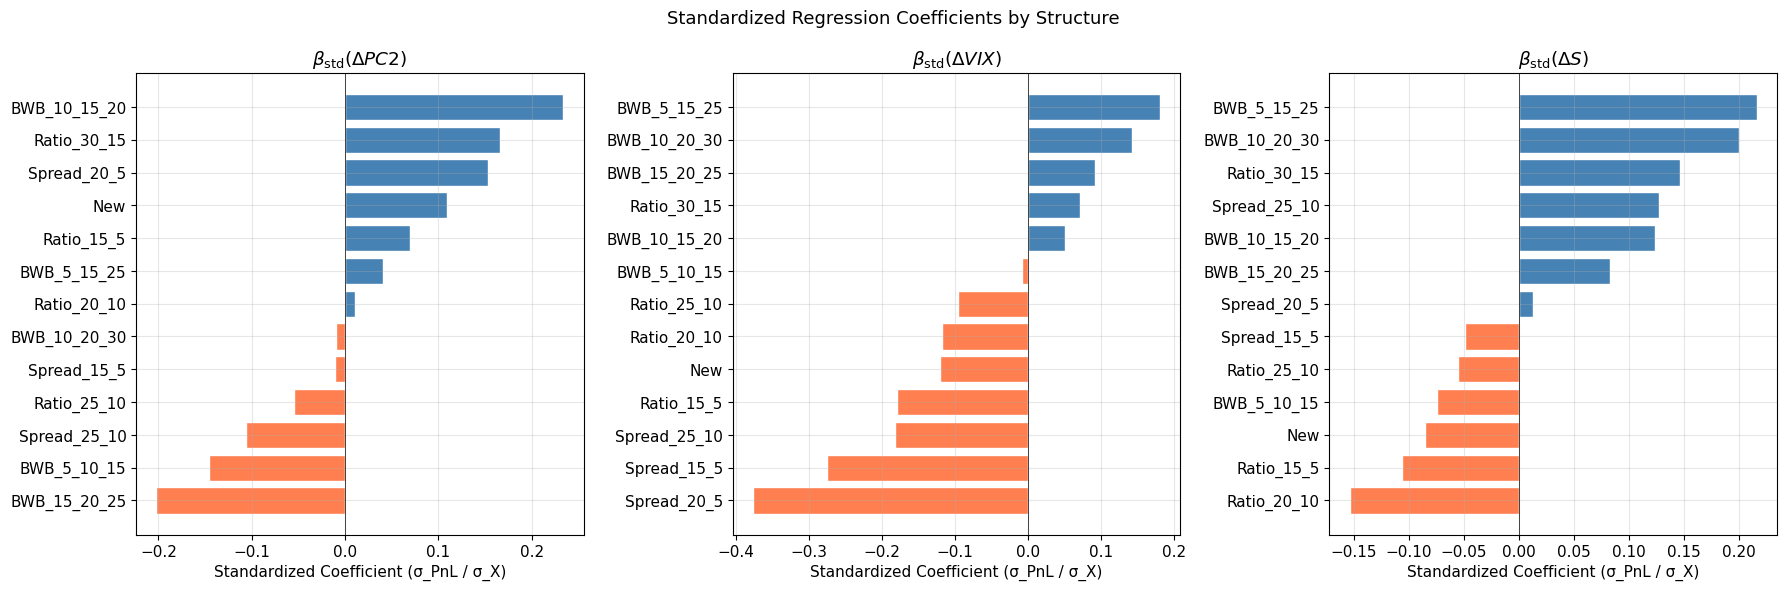

In [19]:
# Standardized coefficient comparison across structures
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(axes,
    ['beta_dpc2', 'beta_dvix', 'beta_dS'],
    [r'$\beta_\mathrm{std}(\Delta PC2)$', r'$\beta_\mathrm{std}(\Delta VIX)$', r'$\beta_\mathrm{std}(\Delta S)$']):

    vals = reg_df.sort(col, descending=True)
    names = vals['structure'].to_list()
    betas = vals[col].to_numpy()
    colors = ['steelblue' if v >= 0 else 'coral' for v in betas]

    ax.barh(names[::-1], betas[::-1], color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Standardized Coefficient (σ_PnL / σ_X)')
    ax.set_title(title)
    ax.axvline(0, color='k', linewidth=0.5)

fig.suptitle('Standardized Regression Coefficients by Structure', fontsize=13)
fig.tight_layout()
plt.show()

## 7. Structure Ranking

Final ranking by standardized $\Delta$PC2 regression $\beta$, which gives the purest measure of each structure's sensitivity to PC2 after controlling for $\Delta$VIX and $\Delta S$.

Standardized $\beta$s are dimensionless — directly comparable across structures regardless of each structure's raw PnL variance.

- **Positive $\beta(\Delta$PC2)**: shorting this structure profits when PC2 increases (skew steepens)
- **Negative $\beta(\Delta$PC2)**: shorting this structure profits when PC2 decreases (skew flattens)

For a mean-reversion strategy:
- When PC2 is **high** (steep, expect compression) → short structures with positive $\beta$
- When PC2 is **low** (flat, expect steepening) → long structures with positive $\beta$

In [20]:
print('STRUCTURE RANKING BY dPC2 STANDARDIZED LOADING')
print('='*100)
print(f'{"Rank":>4s}  {"Structure":20s}  {"β_std(dPC2)":>12s}  {"t-stat":>8s}  '
      f'{"p-val":>8s}  {"corr(dPC2)":>10s}  {"R2":>6s}  {"mean_pnl":>10s}')
print('-' * 100)

for i, row in enumerate(reg_df.iter_rows(named=True)):
    name = row['structure']
    c = corr_delta_pc2[name]
    mp = mean_pnl[name]
    print(f'{i+1:4d}  {name:20s}  {row["beta_dpc2"]:>+12.3f}  {row["t_dpc2"]:>+8.2f}  '
          f'{row["p_dpc2"]:>8.3f}  {c:>+10.3f}  {row["r2"]:>6.3f}  {mp:>+10.2f}')

print(f'\n--- Interpretation ---')
top = reg_df.row(0, named=True)
bot = reg_df.row(-1, named=True)
print(f'Highest dPC2 loading: {top["structure"]} (β_std={top["beta_dpc2"]:+.3f})')
print(f'  -> Shorting this profits most when skew steepens')
print(f'Lowest dPC2 loading:  {bot["structure"]} (β_std={bot["beta_dpc2"]:+.3f})')
print(f'  -> Shorting this profits most when skew flattens')

STRUCTURE RANKING BY dPC2 STANDARDIZED LOADING
Rank  Structure              β_std(dPC2)    t-stat     p-val  corr(dPC2)      R2    mean_pnl
----------------------------------------------------------------------------------------------------
   1  BWB_10_15_20                +0.234     +2.22     0.029      +0.393   0.075       -4.46
   2  Ratio_30_15                 +0.166     +1.56     0.123      +0.427   0.048     +133.04
   3  Spread_20_5                 +0.153     +1.55     0.125      +0.321   0.185     +163.83
   4  New                         +0.110     +1.01     0.316      +0.402   0.016     +489.33
   5  Ratio_15_5                  +0.069     +0.64     0.525      +0.272   0.018     +298.73
   6  BWB_5_15_25                 +0.040     +0.37     0.709      +0.347   0.025       -1.30
   7  Ratio_20_10                 +0.010     +0.10     0.924      +0.371   0.010      +46.97
   8  BWB_10_20_30                -0.009     -0.09     0.931      +0.113   0.017      +76.45
   9  Spread_15